In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.express as px

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Cargar datos
# saber Pro
df_pro = pd.read_csv("Dataset_Final_LimpioSaberPro.csv", encoding='utf-8')

In [3]:
# Saber 11 (archivo aparte)
df_saber11 = pd.read_csv("datos_filtradoSaber11.csv", encoding='utf-8')

In [4]:
df_keys = pd.read_csv("ids_sb11_sbpro_filtrados.csv")

In [5]:
df_pro.columns = df_pro.columns.str.lower()
df_saber11.columns = df_saber11.columns.str.lower()
df_keys.columns = df_keys.columns.str.lower()

In [6]:
# ===============================
# 2. FILTRAR PRUEBAS DE GESTIÓN
# ===============================

gestion = [
    "GESTIÓN DE ORGANIZACIONES",
    "GESTIÓN FINANCIERA",
    "ANÁLISIS ECONÓMICO",
    "INFORMACIÓN Y CONTROL CONTABLE",
    "FORMULACIÓN, EVALUACIÓN Y GESTIÓN DE PROYECTOS"
]

df_pro_gestion = df_pro[
    df_pro["result_nombreprueba"].isin(gestion)
].copy()

In [7]:
# ===============================
# 3. UNIONES
# ===============================

df_pro_keyed = pd.merge(
    df_pro_gestion,
    df_keys,
    left_on="estu_consecutivo",
    right_on="estu_consecutivo_sbpro",
    how="inner"
)

df_full = pd.merge(
    df_pro_keyed,
    df_saber11,
    left_on="estu_consecutivo_sb11",
    right_on="estu_consecutivo",
    how="inner",
    suffixes=("_pro", "_sb11")
)

print("Dataset completo:", df_full.shape)

Dataset completo: (2901, 114)


In [8]:
# ===============================
# 4. VARIABLES PARA CLUSTERING
# ===============================

vars_11 = [
    "punt_lectura_critica",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_ingles"
]

vars_pro = [
    "mod_lectura_critica_punt",
    "mod_comuni_escrita_punt",
    "mod_razona_cuantitat_punt",
    "mod_competen_ciudada_punt",
    "mod_ingles_punt"
]

vars_cluster = vars_pro + vars_11

# 🔴 IMPORTANTE: mantener dataset completo
df_model = df_full.copy()

# dataset SOLO para clustering (sin perder índices)
df_cluster = df_model[vars_cluster].dropna().copy()
df_cluster = df_cluster.sort_index()

print("Observaciones finales:", df_cluster.shape)

Observaciones finales: (1752, 10)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

In [10]:
pip install scikit-fuzzy

In [11]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import skfuzzy as fuzz
import numpy as np

In [12]:
def evaluar_clustering(X, labels, nombre):

    # DBSCAN puede tener ruido (-1)
    if len(set(labels)) <= 1 or (len(set(labels)) == 2 and -1 in labels):
        print(f"{nombre}: No se puede evaluar correctamente (clusters insuficientes)")
        return None

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    print(f"\n===== {nombre} =====")
    print("Silhouette:", round(sil, 4))
    print("Davies-Bouldin:", round(db, 4))
    print("Calinski-Harabasz:", round(ch, 2))

    return sil, db, ch

In [13]:
kmeans = KMeans(n_clusters=4, random_state=100, n_init=100)
labels_kmeans = kmeans.fit_predict(X_scaled)

evaluar_clustering(X_scaled, labels_kmeans, "KMeans")


===== KMeans =====
Silhouette: 0.1435
Davies-Bouldin: 1.8222
Calinski-Harabasz: 406.38


(np.float64(0.14350508178624805),
 np.float64(1.822228968371867),
 np.float64(406.37837403803405))

In [15]:
gmm = GaussianMixture(n_components=4, random_state=100)
labels_gmm = gmm.fit_predict(X_scaled)

evaluar_clustering(X_scaled, labels_gmm, "GMM")


===== GMM =====
Silhouette: 0.0926
Davies-Bouldin: 5.0952
Calinski-Harabasz: 125.77


(np.float64(0.09258770688949751),
 np.float64(5.095159420791861),
 np.float64(125.77014240656752))

In [22]:
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_scaled.T, c=4, m=2, error=0.005, maxiter=1000
)

labels_fcm = np.argmax(u, axis=0)

evaluar_clustering(X_scaled, labels_fcm, "Fuzzy C-Means")


===== Fuzzy C-Means =====
Silhouette: 0.062
Davies-Bouldin: 2.814
Calinski-Harabasz: 364.5


(np.float64(0.062005916092920985),
 np.float64(2.8140017715038157),
 np.float64(364.49717413785004))

In [18]:
agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_scaled)

evaluar_clustering(X_scaled, labels_agg, "Agglomerative")


===== Agglomerative =====
Silhouette: 0.1053
Davies-Bouldin: 1.9053
Calinski-Harabasz: 330.53


(np.float64(0.10530482487282514),
 np.float64(1.9053242771390868),
 np.float64(330.5323989578223))

In [24]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_scaled)

evaluar_clustering(X_scaled, labels_dbscan, "DBSCAN")


===== DBSCAN =====
Silhouette: 0.0727
Davies-Bouldin: 5.6094
Calinski-Harabasz: 20.13


(np.float64(0.0726594491552764),
 np.float64(5.609416004775624),
 np.float64(20.127228718581556))

In [16]:
spectral = SpectralClustering(n_clusters=4, assign_labels='kmeans', random_state=100)
labels_spectral = spectral.fit_predict(X_scaled)

evaluar_clustering(X_scaled, labels_spectral, "Spectral Clustering")


===== Spectral Clustering =====
Silhouette: 0.3699
Davies-Bouldin: 0.5998
Calinski-Harabasz: 17.71


(np.float64(0.36986478705204817),
 np.float64(0.5997878761947916),
 np.float64(17.714251749571535))

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
def graficar_clusters(X_pca, labels, titulo):

    plt.figure()
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels
    )

    plt.title(titulo)
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.show()

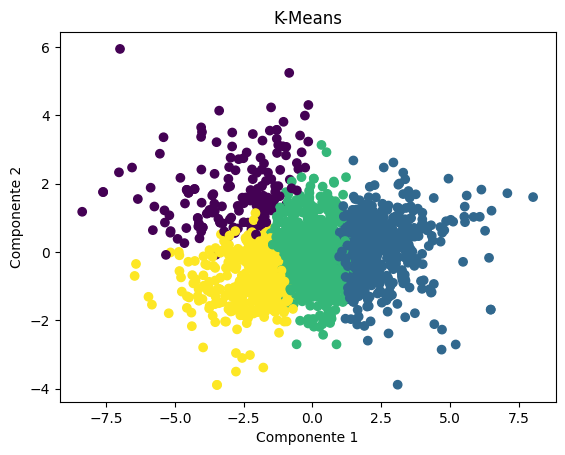

In [ ]:
graficar_clusters(X_pca, labels_kmeans, "K-Means")

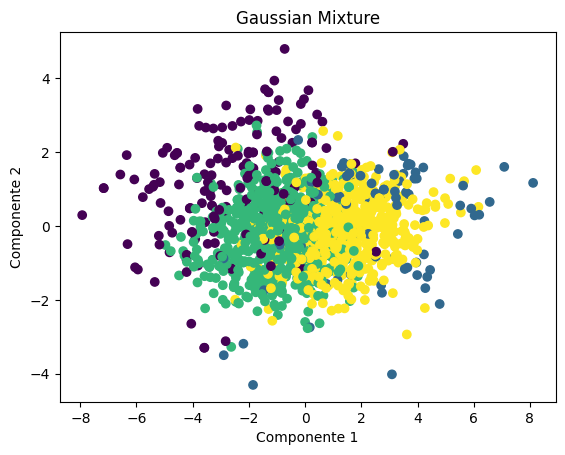

In [ ]:
graficar_clusters(X_pca, labels_gmm, "Gaussian Mixture")

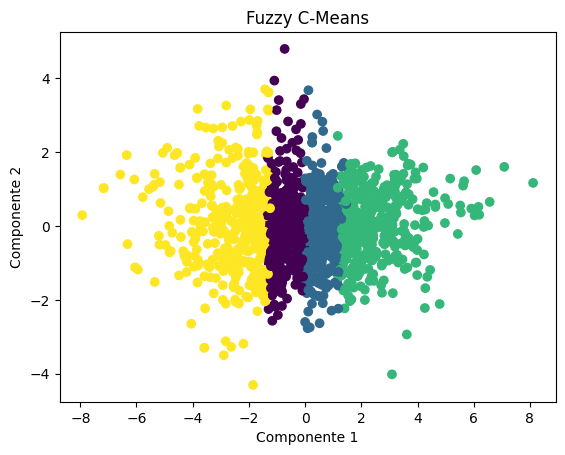

In [ ]:
graficar_clusters(X_pca, labels_fcm, "Fuzzy C-Means")

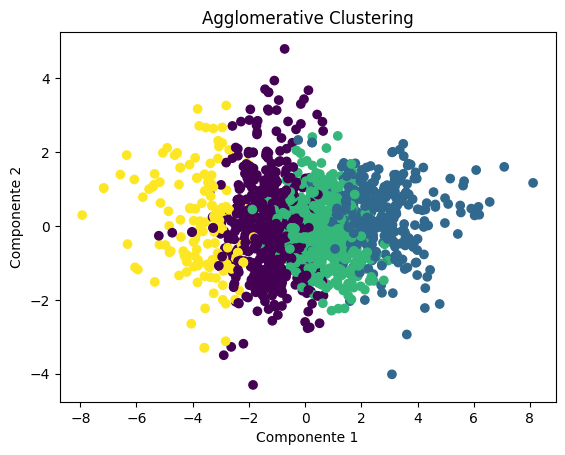

In [ ]:
graficar_clusters(X_pca, labels_agg, "Agglomerative Clustering")

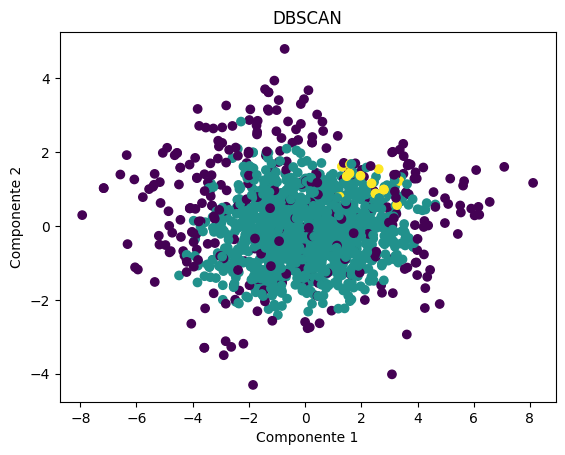

In [ ]:
graficar_clusters(X_pca, labels_dbscan, "DBSCAN")

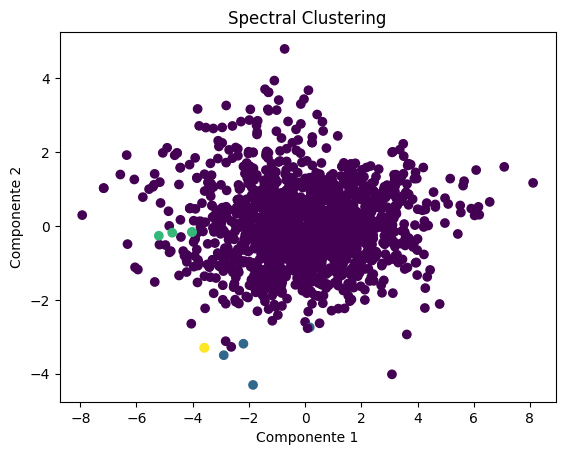

In [ ]:
graficar_clusters(X_pca, labels_spectral, "Spectral Clustering")

In [ ]:
df_cluster["cluster"] = labels_kmeans
df_cluster["puntaje_total"] = df_cluster.mean(axis=1)

df_cluster.groupby("cluster")[vars_cluster].mean()

,mod_lectura_critica_punt,mod_comuni_escrita_punt,mod_razona_cuantitat_punt,mod_competen_ciudada_punt,mod_ingles_punt,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_ingles
cluster,,,,,,,,,,
0,117.771605,114.401235,137.734568,106.148148,167.679012,61.043210,65.722222,61.611111,62.561728,72.481481
1,198.027624,169.944751,200.486188,196.263352,211.896869,71.657459,78.152855,73.618785,74.108656,81.139963
2,173.854467,163.004323,178.340058,171.606628,195.275216,64.645533,68.845821,65.914986,66.963977,74.396254
3,161.079320,150.291785,163.725212,157.345609,169.634561,58.152975,60.923513,58.093484,59.269122,59.665722


In [ ]:
map_clusters = {
    2: 0,  # bajo
    0: 1,  # medio-bajo
    3: 2,  # medio-alto
    1: 3   # alto
}

df_cluster["nivel"] = df_cluster["cluster"].map(map_clusters)

In [ ]:
df_cluster["cluster"] = labels_kmeans
df_cluster["puntaje_total"] = df_cluster.mean(axis=1)

In [ ]:
df_cluster["cluster"] = labels_kmeans
df_cluster["puntaje_total"] = df_cluster.mean(axis=1)

df_cluster.groupby("cluster")[vars_cluster].mean()

,mod_lectura_critica_punt,mod_comuni_escrita_punt,mod_razona_cuantitat_punt,mod_competen_ciudada_punt,mod_ingles_punt,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_ingles
cluster,,,,,,,,,,
0,117.771605,114.401235,137.734568,106.148148,167.679012,61.043210,65.722222,61.611111,62.561728,72.481481
1,198.027624,169.944751,200.486188,196.263352,211.896869,71.657459,78.152855,73.618785,74.108656,81.139963
2,173.854467,163.004323,178.340058,171.606628,195.275216,64.645533,68.845821,65.914986,66.963977,74.396254
3,161.079320,150.291785,163.725212,157.345609,169.634561,58.152975,60.923513,58.093484,59.269122,59.665722


In [ ]:
# 🔗 Unir clusters al dataset completo
df_model = df_model.loc[df_cluster.index].copy()
df_model["cluster"] = df_cluster["cluster"]

In [ ]:
pd.crosstab(df_model["cole_area_ubicacion"], df_model["cluster"])

cluster,0,1,2,3
cole_area_ubicacion,,,,
RURAL,21,50,83,36
URBANO,141,493,611,317


In [ ]:
print(df_model.columns)

Index(['periodo_pro', 'estu_consecutivo_pro', 'estu_tipodocumento_pro',
       'estu_pais_reside_pro', 'estu_cod_reside_depto_pro',
       'estu_depto_reside_pro', 'estu_cod_reside_mcpio_pro',
       'estu_mcpio_reside_pro', 'estu_coddane_cole_termino',
       'estu_cod_cole_mcpio_termino',
       ...
       'fami_tieneinternet_sb11', 'fami_tienelavadora_sb11', 'desemp_ingles',
       'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas',
       'punt_c_naturales', 'punt_lectura_critica', 'punt_global', 'cluster'],
      dtype='object', length=115)


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [ ]:
# ❌ columnas que NO queremos evaluar
excluir = vars_cluster + [
    "cluster",
    "puntaje_total",
    "estu_consecutivo",
    "estu_consecutivo_pro",
    "estu_consecutivo_sb11"
]

# 👉 seleccionar candidatas automáticamente
vars_candidatas = [
    col for col in df_model.columns
    if col not in excluir
]

In [ ]:
vars_finales = []

for col in vars_candidatas:
    serie = df_model[col]

    # 🔥 evitar columnas duplicadas o mal formadas
    if isinstance(serie, pd.DataFrame):
        continue

    # quitar columnas con muchos nulos
    if serie.isna().mean() > 0.4:
        continue

    # quitar columnas con una sola categoría
    if serie.nunique() < 2:
        continue

    # quitar columnas con demasiadas categorías (tipo IDs)
    if serie.nunique() > 50:
        continue

    vars_finales.append(col)

print("Variables finales a evaluar:", len(vars_finales))

Variables finales a evaluar: 71


In [ ]:
for col in df_model.columns:
    if isinstance(df_model[col], pd.DataFrame):
        print("Columna problemática:", col)

Columna problemática: estu_consecutivo_sb11
Columna problemática: periodo_sb11
Columna problemática: periodo_sb11
Columna problemática: estu_consecutivo_sb11


In [ ]:
resultados = []

for var in vars_finales:
    try:
        df_temp = df_model[[var, "cluster"]].dropna()

        # evitar problemas con pocas observaciones
        if df_temp.shape[0] < 50:
            continue

        v = cramers_v(df_temp[var], df_temp["cluster"])

        resultados.append({
            "variable": var,
            "cramers_v": v,
            "n": len(df_temp),
            "categorias": df_temp[var].nunique()
        })

    except Exception as e:
        print(f"Error con {var}: {e}")

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="cramers_v", ascending=False)

print(df_resultados.head(15))

                          variable  cramers_v     n  categorias
70                   desemp_ingles   0.375496  1752           5
39                mod_ingles_desem   0.332894  1752           5
23        estu_snies_prgmacademico   0.331348  1752          11
9           estu_inst_departamento   0.274917  1752           2
13          estu_prgm_departamento   0.274917  1752           2
7          inst_nombre_institucion   0.264226  1752           5
6             inst_cod_institucion   0.264226  1752           5
8             estu_nucleo_pregrado   0.256528  1752           3
11             estu_inst_municipio   0.238333  1752           3
15             estu_prgm_municipio   0.238333  1752           3
10          estu_inst_codmunicipio   0.238333  1752           3
14          estu_prgm_codmunicipio   0.238333  1752           3
16  estu_valormatriculauniversidad   0.229408  1744           8
12             estu_prgm_academico   0.213303  1752           4
37                     inst_origen   0.2

In [ ]:
excluir_extra = [
    "inst_cod_institucion",
    "inst_nombre_institucion",
    "estu_snies_prgmacademico",
    "estu_prgm_academico",
    "estu_nucleo_pregrado"
]

vars_finales = [v for v in vars_finales if v not in excluir_extra]

In [ ]:
excluir_extra = [
    # institucionales
    "inst_cod_institucion",
    "inst_nombre_institucion",
    "inst_origen",

    # programas
    "estu_snies_prgmacademico",
    "estu_prgm_academico",
    "estu_nucleo_pregrado",

    # ubicación institucional
    "estu_prgm_departamento",
    "estu_inst_departamento",
    "estu_prgm_municipio",
    "estu_inst_municipio",
    "estu_prgm_codmunicipio",
    "estu_inst_codmunicipio",

    # ubicación colegio muy específica (opcional)
    "cole_cod_depto_ubicacion",
    "cole_depto_ubicacion",
    "estu_depto_presentacion_sb11",

    # desempeño (si quieres enfocarte solo en socioeconómico)
    "mod_ingles_desem",
    "desemp_ingles",
    "mod_comuni_escrita_desem",
    "result_nombreprueba"
]

vars_finales = [v for v in vars_finales if v not in excluir_extra]

In [ ]:
resultados = []

for var in vars_finales:
    try:
        df_temp = df_model[[var, "cluster"]].dropna()

        # evitar problemas con pocas observaciones
        if df_temp.shape[0] < 50:
            continue

        v = cramers_v(df_temp[var], df_temp["cluster"])

        resultados.append({
            "variable": var,
            "cramers_v": v,
            "n": len(df_temp),
            "categorias": df_temp[var].nunique()
        })

    except Exception as e:
        print(f"Error con {var}: {e}")

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="cramers_v", ascending=False)

print(df_resultados.head(15))

                            variable  cramers_v     n  categorias
6     estu_valormatriculauniversidad   0.229408  1744           8
49         fami_tienecomputador_sb11   0.205542  1744           2
34                   cole_naturaleza   0.193308  1752           2
51           fami_tienelavadora_sb11   0.189282  1746           2
37        estu_cod_reside_depto_sb11   0.185888  1752          28
38            estu_depto_reside_sb11   0.185888  1752          28
36  estu_cod_depto_presentacion_sb11   0.184213  1752          28
3          estu_cod_reside_depto_pro   0.181719  1751          21
4              estu_depto_reside_pro   0.181719  1751          21
50           fami_tieneinternet_sb11   0.176866  1735           2
48          fami_tieneautomovil_sb11   0.165535  1743           2
46         fami_estratovivienda_sb11   0.146676  1738           7
29                     cole_bilingue   0.136988  1604           2
22          fami_estratovivienda_pro   0.135116  1694           7
40        

In [ ]:
resultados = []

for var in vars_finales:
    try:
        df_temp = df_model[[var, "cluster"]].dropna()

        # evitar problemas con pocas observaciones
        if df_temp.shape[0] < 50:
            continue

        v = cramers_v(df_temp[var], df_temp["cluster"])

        resultados.append({
            "variable": var,
            "cramers_v": v,
            "n": len(df_temp),
            "categorias": df_temp[var].nunique()
        })

    except Exception as e:
        print(f"Error con {var}: {e}")

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="cramers_v", ascending=False)

print(df_resultados.head(15))

                            variable  cramers_v     n  categorias
6     estu_valormatriculauniversidad   0.229408  1744           8
49         fami_tienecomputador_sb11   0.205542  1744           2
34                   cole_naturaleza   0.193308  1752           2
51           fami_tienelavadora_sb11   0.189282  1746           2
37        estu_cod_reside_depto_sb11   0.185888  1752          28
38            estu_depto_reside_sb11   0.185888  1752          28
36  estu_cod_depto_presentacion_sb11   0.184213  1752          28
3          estu_cod_reside_depto_pro   0.181719  1751          21
4              estu_depto_reside_pro   0.181719  1751          21
50           fami_tieneinternet_sb11   0.176866  1735           2
48          fami_tieneautomovil_sb11   0.165535  1743           2
46         fami_estratovivienda_sb11   0.146676  1738           7
29                     cole_bilingue   0.136988  1604           2
22          fami_estratovivienda_pro   0.135116  1694           7
40        

In [ ]:
# Ver dataset final unido
print("\n" + "="*80)
print("DATASET FINAL (df_full) - DESPUÉS DE LA UNIÓN")
print("="*80)

if 'df_full' in globals():
    print(f"\nShape: {df_full.shape}")
    print(f"Columnas totales: {len(df_full.columns)}")
    print("\n📋 Lista completa de columnas:")

    # Separar por origen
    cols_pro = [col for col in df_full.columns if col.endswith('_pro') or col in df_pro.columns]
    cols_sb11 = [col for col in df_full.columns if col.endswith('_sb11') or col in df_saber11.columns]
    cols_keys = [col for col in df_full.columns if col in df_keys.columns]

    print("\n🔹 Columnas de Saber Pro:")
    for col in sorted(cols_pro)[:20]:  # Mostrar primeras 20
        print(f"   - {col}")

    print("\n🔹 Columnas de Saber 11:")
    for col in sorted(cols_sb11)[:20]:
        print(f"   - {col}")

    print("\n🔹 Columnas de keys:")
    for col in cols_keys:
        print(f"   - {col}")
else:
    print("df_full no está definido aún")


DATASET FINAL (df_full) - DESPUÉS DE LA UNIÓN

Shape: (2901, 114)
Columnas totales: 114

📋 Lista completa de columnas:

🔹 Columnas de Saber Pro:
   - estu_cod_cole_mcpio_termino
   - estu_cod_depto_presentacion_pro
   - estu_cod_mcpio_presentacion_pro
   - estu_cod_reside_depto_pro
   - estu_cod_reside_mcpio_pro
   - estu_coddane_cole_termino
   - estu_cole_termino
   - estu_consecutivo_pro
   - estu_depto_presentacion_pro
   - estu_depto_reside_pro
   - estu_estadoinvestigacion_pro
   - estu_estudiante_pro
   - estu_fechanacimiento_pro
   - estu_genero_pro
   - estu_horassemanatrabaja
   - estu_inst_codmunicipio
   - estu_inst_departamento
   - estu_inst_municipio
   - estu_mcpio_presentacion_pro
   - estu_mcpio_reside_pro

🔹 Columnas de Saber 11:
   - cole_area_ubicacion
   - cole_bilingue
   - cole_calendario
   - cole_caracter
   - cole_cod_dane_establecimiento
   - cole_cod_dane_sede
   - cole_cod_depto_ubicacion
   - cole_cod_mcpio_ubicacion
   - cole_codigo_icfes
   - cole_dept